# Camada Sintética, Baseline, Thompson Sampling e MLflow

## Contexto

A base original registra apenas se o cliente aceitou ou não uma campanha. Como o multi-armed Bandit precisa comparar diferentes opções, foram criadas algumas ofertas simuladas para o experimento.

- **Contexto:** informações de cada cliente usadas pelo modelo.
- **Braços:** quatro ofertas diferentes que podem ser apresentadas ao cliente.
- **Conversão:** cada oferta possui uma chance de conversão que o modelo tenta aprender ao longo das interações.
- **Referência:** a taxa real de conversão da base foi usada como ponto de partida para a oferta `No Incentive`, enquanto as demais ofertas receberam pequenas variações simuladas.

O **Baseline** e o **Thompson Sampling** utilizam o mesmo cenário de simulação para permitir uma comparação consistente entre as estratégias.

In [0]:
import sys

BASE = "/Workspace/Users/jessyca.oliveira@databricks.com/[FIAP] Fase 5"
sys.path.insert(0, f"{BASE}/src")

import numpy as np
import pandas as pd

CATALOG, SCHEMA = "jessyca_demos", "datathon"
SEED = 42
N_ROUNDS = 8000

### 1) Carregar a base limpa

Leitura da tabela `bank_clean`, gerada no Notebook 01. São amostrados `N_ROUNDS` clientes para servir de contexto na simulação, de forma reprodutível pela semente.

In [0]:
from bandits.preprocess import feature_columns, sample_for_simulation

df = spark.table(f"{CATALOG}.{SCHEMA}.bank_clean").toPandas()

sample = sample_for_simulation(df, n_rounds=N_ROUNDS, seed=SEED)
cats, nums = feature_columns(sample)

### 2) Catálogo de ofertas

Cada oferta tem uma margem (quanto o banco ganha se o cliente converter) e um incremento de conversão (`uplift`) em relação ao braço de referência. Ofertas mais generosas tendem a converter mais, porém com margem menor. A recompensa esperada de uma oferta é `probabilidade de conversão × margem`.

In [0]:
from bandits.synthetic import OFFER_CATALOG

display(OFFER_CATALOG)

arm,offer_name,margin,uplift
0,No Incentive,1.0,0.0
1,Fee Discount,0.85,0.45
2,Cashback,0.7,0.8
3,Premium Bundle,0.55,1.1


### 3) Contexto e mundo verdadeiro

Nesta etapa, os dados são preparados para que possam ser usados na simulação do Multi-Armed Bandit.

- `build_context_matrix`: transforma as informações dos clientes em valores numéricos que o modelo consegue utilizar.
- `build_true_reward_model`: define uma probabilidade simulada de conversão para cada oferta, usando como referência a taxa real de conversão encontrada na base.

In [0]:
from bandits.synthetic import (
    build_context_matrix,
    build_true_reward_model,
    generate_logged_interactions,
)

contexts, feature_pipeline = build_context_matrix(
    sample, cats, nums, n_components=8, seed=SEED
)
all_probs, margins, _ = build_true_reward_model(
    contexts, sample["y"].to_numpy(), OFFER_CATALOG, seed=SEED
)

print("dimensão do contexto:", contexts.shape)
print("\nProbabilidade média de conversão por braço (desconhecida das políticas):")
for i, name in enumerate(OFFER_CATALOG["offer_name"]):
    er = (all_probs[:, i] * margins[i]).mean()
    print(f"  {name:15s}  p_conv={all_probs[:, i].mean():.3f}  margem={margins[i]:.2f}  recompensa_esperada={er:.3f}")

dimensão do contexto: (8000, 8)

Probabilidade média de conversão por braço (desconhecida das políticas):
  No Incentive     p_conv=0.204  margem=1.00  recompensa_esperada=0.204
  Fee Discount     p_conv=0.220  margem=0.85  recompensa_esperada=0.187
  Cashback         p_conv=0.330  margem=0.70  recompensa_esperada=0.231
  Premium Bundle   p_conv=0.261  margem=0.55  recompensa_esperada=0.144


### 4) Recompensas atrasadas

Na prática, a resposta de um cliente pode levar algum tempo para acontecer. Para representar esse cenário, cada decisão recebe um pequeno atraso antes que o resultado seja conhecido.

Assim, o modelo só aprende com uma decisão depois que o retorno do cliente fica disponível, tornando a simulação mais próxima de uma situação real.

Atraso médio das recompensas: 1.78 rounds


<Axes: title={'center': 'Distribuição do atraso (delay_steps)'}, ylabel='Frequency'>

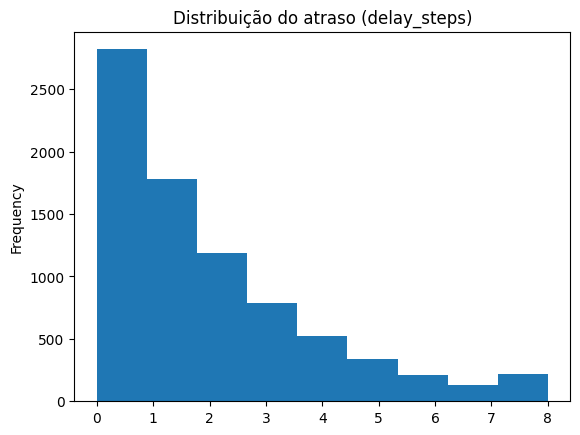

In [0]:
logged = generate_logged_interactions(all_probs, margins, epsilon=0.35,
                                       delay_p=0.35, max_delay=8, seed=SEED)
print("Atraso médio das recompensas:", round(logged["delay_steps"].mean(), 2), "rounds")
logged["delay_steps"].plot(kind="hist", bins=9, title="Distribuição do atraso (delay_steps)")

### 5) As políticas

Nesta simulação, são comparadas duas formas de escolher qual oferta apresentar ao cliente:

| Política | Como funciona |
|:--|:--|
| **Baseline** | Sempre escolhe a mesma oferta. Serve como referência para comparação e não aprende com os resultados. |
| **Thompson Sampling** | Aprende com as respostas dos clientes e ao longo do tempo tenta escolher as ofertas com maior chance de trazer bons resultados. |

Foi utilizado o **Thompson Sampling** como estratégia adaptativa. No início, como ainda não existem informações suficientes sobre qual oferta é melhor, todas começam com as mesmas condições. Conforme os clientes respondem, o algoritmo atualiza o que aprendeu e passa a favorecer as ofertas que apresentam melhores resultados.

Esse comportamento permite equilibrar a tentativa de explorar diferentes ofertas e ao mesmo tempo, aproveitar aquelas que já demonstraram bom desempenho.

In [0]:
from bandits.policies import build_policy
from bandits.simulator import run_policy_simulation, summarize_simulations

n_arms = len(OFFER_CATALOG)

# Baseline: braço 0 ("No Incentive") como regra fixa de controle.
policies = {
    "Baseline Determinístico": build_policy("baseline", n_arms, margins, fixed_arm=0),
    "Thompson Sampling":       build_policy("thompson", n_arms, margins, seed=SEED),
}

### 6) Simulação

As duas estratégias são testadas nas mesmas condições e com os mesmos dados de simulação. Dessa forma, a comparação fica mais justa e as diferenças observadas nos resultados estão mais relacionadas à forma como cada política toma suas decisões.

In [0]:
sims = []
ts_policy = None
for name, pol in policies.items():
    sim = run_policy_simulation(name, pol, all_probs, margins,
                                delay_p=0.35, max_delay=8, seed=100)
    sims.append(sim)
    if name == "Thompson Sampling":
        ts_policy = pol

sim_all = pd.concat(sims, ignore_index=True)
summary = summarize_simulations(sim_all)
display(summary)

policy,total_reward,cumulative_regret,conversion_rate,exploration_share
Thompson Sampling,1774.1499999999999,312.29465763115377,0.31025,0.120875
Baseline Determinístico,1576.0,481.67327774688687,0.197,0.0


%md
### 7) Leitura dos resultados

Para comparar as duas estratégias, foram utilizadas algumas métricas:

- **Recompensa total:** soma dos resultados positivos obtidos. Quanto maior, melhor.
- **Arrependimento acumulado:** representa o quanto a estratégia deixou de ganhar por não escolher sempre a melhor oferta. Quanto menor, melhor.
- **Taxa de conversão:** percentual de clientes que aceitaram a oferta.
- **Fração de exploração:** indica com que frequência a estratégia testou outras ofertas em vez de escolher apenas aquela que parecia ser a melhor.

In [0]:
base_reward = summary.loc[summary.policy == "Baseline Determinístico", "total_reward"].iloc[0]
for _, row in summary.iterrows():
    lift = 100 * (row["total_reward"] - base_reward) / base_reward
    print(f"{row['policy']:26s} | reward={row['total_reward']:8.1f} "
          f"| conv={row['conversion_rate']:.3f} | regret={row['cumulative_regret']:7.1f} "
          f"| ganho vs baseline: {lift:+.1f}%")

Thompson Sampling          | reward=  1774.1 | conv=0.310 | regret=  312.3 | ganho vs baseline: +12.6%
Baseline Determinístico    | reward=  1576.0 | conv=0.197 | regret=  481.7 | ganho vs baseline: +0.0%


### 8) Curvas de aprendizado

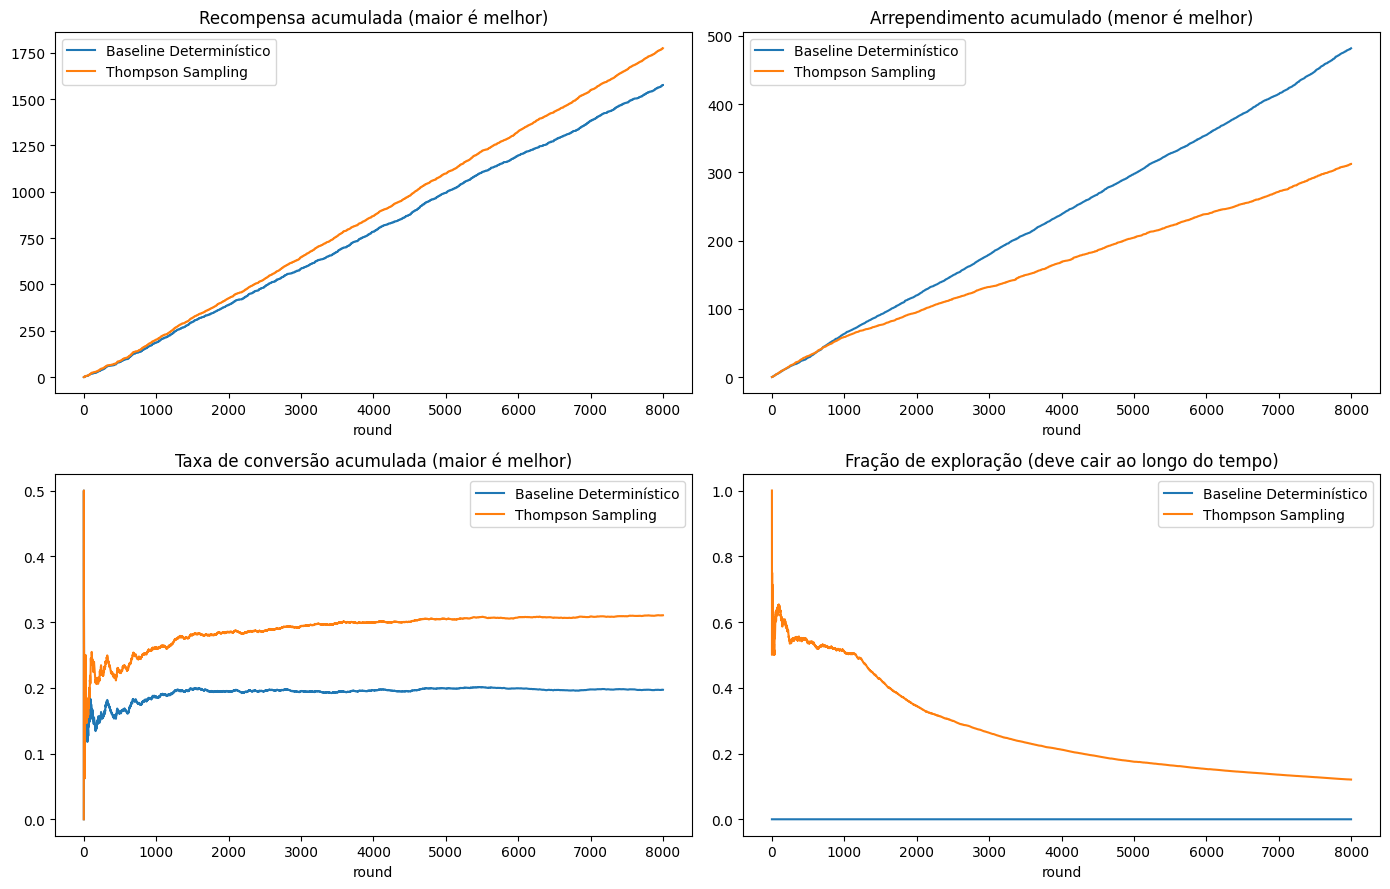

In [0]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for name in policies:
    s = sim_all[sim_all.policy == name]
    axes[0, 0].plot(s["round"], s["cum_reward"], label=name)
    axes[0, 1].plot(s["round"], s["cum_regret"], label=name)
    axes[1, 0].plot(s["round"], s["cum_conversion_rate"], label=name)
    axes[1, 1].plot(s["round"], s["cum_exploration_share"], label=name)

axes[0, 0].set_title("Recompensa acumulada (maior é melhor)")
axes[0, 1].set_title("Arrependimento acumulado (menor é melhor)")
axes[1, 0].set_title("Taxa de conversão acumulada (maior é melhor)")
axes[1, 1].set_title("Fração de exploração (deve cair ao longo do tempo)")
for ax in axes.flat:
    ax.legend(); ax.set_xlabel("round")
plt.tight_layout()
plt.show()

O Thompson Sampling supera o baseline em recompensa e conversão, com arrependimento menor. A fração de exploração cai ao longo do tempo: no início a política explora bastante (cold-start) e, à medida que aprende, passa a explotar o que descobriu.

### 9) Verificação de sinal no contexto

Como verificação adicional, foi utilizada uma **regressão logística** para avaliar se as informações dos clientes ajudam a prever a variável `y`.

Uma **AUC acima de 0,5** indica que os dados possuem algum poder de previsão e que o modelo consegue identificar padrões melhores do que uma escolha aleatória.

Essa etapa serve apenas como uma validação dos dados utilizados. A estratégia de controle continua sendo a regra fixa definida anteriormente.

In [0]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

X = contexts
y = sample["y"].to_numpy()
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=SEED, stratify=y)
clf = LogisticRegression(max_iter=1000).fit(Xtr, ytr)
auc = roc_auc_score(yte, clf.predict_proba(Xte)[:, 1])
print(f"AUC da regressão logística sobre o contexto: {auc:.3f}")

AUC da regressão logística sobre o contexto: 0.724


### 10) Registro no MLflow

Os parâmetros e resultados do experimento foram registrados no **MLflow**, ferramenta integrada ao Databricks para acompanhamento de experimentos de Machine Learning.

Dessa forma, é possível armazenar, consultar e comparar de maneira organizada os resultados das diferentes políticas testadas.

In [0]:
import mlflow

EXPERIMENT = f"/Users/jessyca.oliveira@databricks.com/[FIAP] Fase 5/mlflow_bandits"
mlflow.set_experiment(EXPERIMENT)

params_by_policy = {
    "Baseline Determinístico": {"tipo": "regra_fixa", "fixed_arm": 0},
    "Thompson Sampling": {"tipo": "thompson", "prior": "Beta(1,1)", "cold_start": "prior_uniforme"},
}

with mlflow.start_run(run_name="experimento_bandits"):
    mlflow.log_params({
        "seed": SEED, "n_rounds": N_ROUNDS, "n_arms": n_arms,
        "delay_dist": "geometric(p=0.35)", "max_delay": 8,
        "base_rate_real": round(float(df["y"].mean()), 4),
        "reward_note": "sintetica_calibrada_nao_uplift_producao",
    })
    mlflow.log_metric("logreg_sanity_auc", auc)

    for _, row in summary.iterrows():
        name = row["policy"]
        with mlflow.start_run(run_name=name, nested=True):
            mlflow.log_params(params_by_policy.get(name, {}))
            mlflow.log_metrics({
                "total_reward": float(row["total_reward"]),
                "cumulative_regret": float(row["cumulative_regret"]),
                "conversion_rate": float(row["conversion_rate"]),
                "exploration_share": float(row["exploration_share"]),
                "lift_vs_baseline_pct": 100 * (row["total_reward"] - base_reward) / base_reward,
            })
    print("MLflow: experimento registrado em", EXPERIMENT)

MLflow: experimento registrado em /Users/jessyca.oliveira@databricks.com/[FIAP] Fase 5/mlflow_bandits


## 11) Salvamento dos resultados

As taxas de conversão aprendidas pelo **Thompson Sampling** são salvas para serem utilizadas posteriormente pela API.

Também são armazenadas as tabelas com o histórico da simulação e o resumo dos resultados, facilitando consultas e análises futuras.

In [0]:
import json, os

learned_rates = ts_policy.posterior_mean().tolist()
print("Taxas aprendidas por braço (Thompson posterior):")
for name, r in zip(OFFER_CATALOG["offer_name"], learned_rates):
    print(f"  {name:15s} {r:.4f}")

artifacts_dir = f"{BASE}/artifacts"
os.makedirs(artifacts_dir, exist_ok=True)
payload = {
    "rates": learned_rates,
    "offer_names": OFFER_CATALOG["offer_name"].tolist(),
    "margins": margins.tolist(),
    "seed": SEED,
    "note": "posterior medio do Thompson Sampling; recompensa sintetica calibrada",
}
with open(f"{artifacts_dir}/arm_conversion_rates.json", "w", encoding="utf-8") as f:
    json.dump(payload, f, ensure_ascii=False, indent=2)
print("\nSalvo em:", f"{artifacts_dir}/arm_conversion_rates.json")

spark.createDataFrame(sim_all).write.mode("overwrite").option("overwriteSchema", "true") \
     .saveAsTable(f"{CATALOG}.{SCHEMA}.simulation_history")
spark.createDataFrame(summary).write.mode("overwrite").option("overwriteSchema", "true") \
     .saveAsTable(f"{CATALOG}.{SCHEMA}.policy_summary")
print("Tabelas salvas: simulation_history, policy_summary")

Taxas aprendidas por braço (Thompson posterior):
  No Incentive    0.1811
  Fee Discount    0.1863
  Cashback        0.3269
  Premium Bundle  0.2535

Salvo em: /Workspace/Users/jessyca.oliveira@databricks.com/[FIAP] Fase 5/artifacts/arm_conversion_rates.json
Tabelas salvas: simulation_history, policy_summary


## Resumo

- Construção da camada sintética calibrada na taxa real de conversão.
- Implementação do baseline determinístico e do Thompson Sampling, com recompensas atrasadas e tratamento de cold-start.
- O Thompson Sampling superou o baseline em recompensa e conversão.
- Registro do experimento no MLflow e gravação das taxas aprendidas e das tabelas.